# Activation Functions in Neural Networks (TensorFlow + Keras)

Activation functions introduce **non-linearity** into neural networks, allowing them to learn complex patterns and relationships in data.

Without activation functions, the model would behave like a simple linear regression model — no matter how many layers we add!

---

## Why Do We Need Activation Functions?

They decide **whether a neuron should be activated or not**, by transforming the input signal into an output signal through a mathematical function.

This helps the network:
- Capture **non-linear relationships**
- **Normalize** outputs into a specific range
- Enable **gradient-based learning**

---

## Common Activation Functions Overview

| Function | Equation | Output Range | Typical Use |
|-----------|-----------|---------------|--------------|
| Sigmoid | $\sigma(x) = \frac{1}{1 + e^{-x}}$ | (0, 1) | Binary classification output |
| Tanh | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | (-1, 1) | Hidden layers (better than sigmoid) |
| ReLU | $\max(0, x)$ | [0, ∞) | Default for hidden layers |
| Leaky ReLU | $\max(0.01x, x)$ | (-∞, ∞) | Fixes “dying ReLU” issue |
| ELU | $x$ if $x>0$, $\alpha(e^x - 1)$ otherwise | (-α, ∞) | Robust gradient flow |
| Softmax | $\frac{e^{x_i}}{\sum_j e^{x_j}}$ | (0, 1), sum = 1 | Multi-class classification output |

---

## Setup

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


---

## Sigmoid Activation Function

- **Range:** (0, 1)
- **Use when:** You need probabilities (e.g., binary classification)
- **Drawback:** Saturates (vanishing gradient problem)


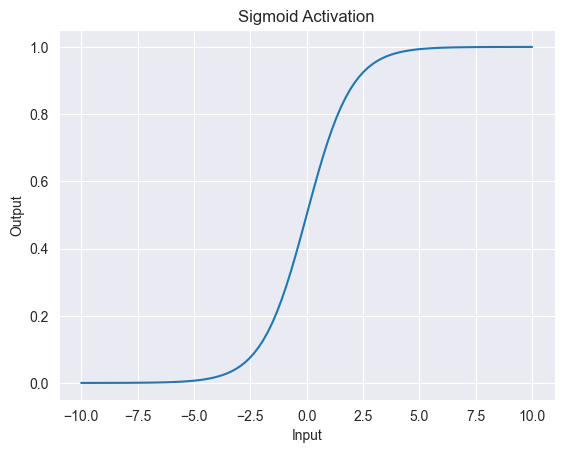

In [2]:
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.title("Sigmoid Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

### Example: Binary Classifier with Sigmoid Output


In [3]:
model_sigmoid = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10,)),
    layers.Dense(1, activation='sigmoid')  # Output between 0 and 1
])

model_sigmoid.summary()


C:\Users\Makrious\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

---

## Tanh Activation Function

- **Range:** (-1, 1)
- **Centered around zero** → faster convergence
- **Use when:** Hidden layers in small networks


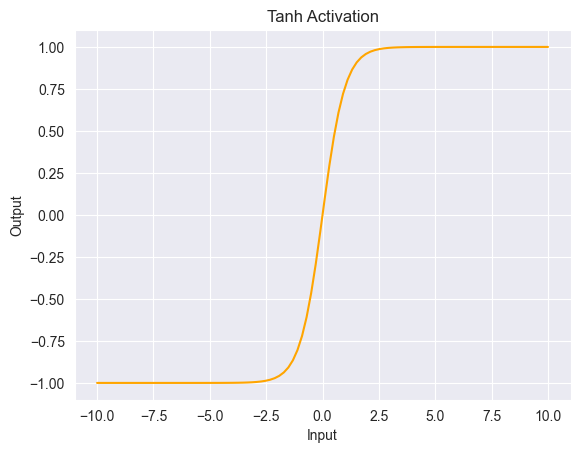

In [4]:
y_tanh = np.tanh(x)

plt.plot(x, y_tanh, color='orange')
plt.title("Tanh Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()


### Example: Hidden Layers Using Tanh


In [5]:
model_tanh = keras.Sequential([
    layers.Dense(32, activation='tanh', input_shape=(10,)),
    layers.Dense(1, activation='sigmoid')
])

model_tanh.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

---

## ReLU (Rectified Linear Unit)

- **Range:** [0, ∞)
- **Fast to compute**, simple, avoids vanishing gradients (for x > 0)
- **Use when:** Default for most hidden layers
- **Drawback:** “Dying ReLU” (neurons stuck at 0 for all inputs)


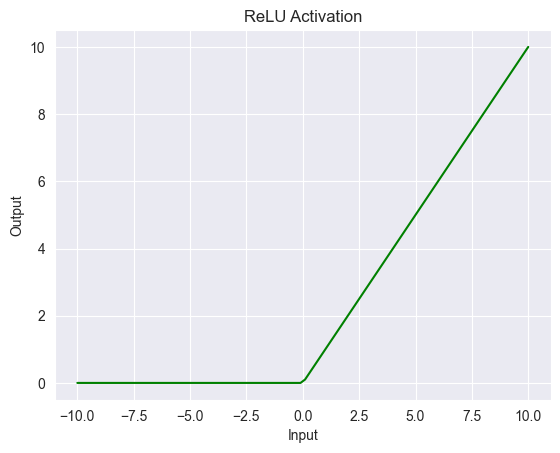

In [6]:
y_relu = np.maximum(0, x)

plt.plot(x, y_relu, color='green')
plt.title("ReLU Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

### Example: ReLU in Hidden Layers

In [7]:
model_relu = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_relu.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

---

## Leaky ReLU

- **Fix for dying ReLU**
- **Allows small negative slope**
- **Use when:** You face dead neurons in ReLU layers


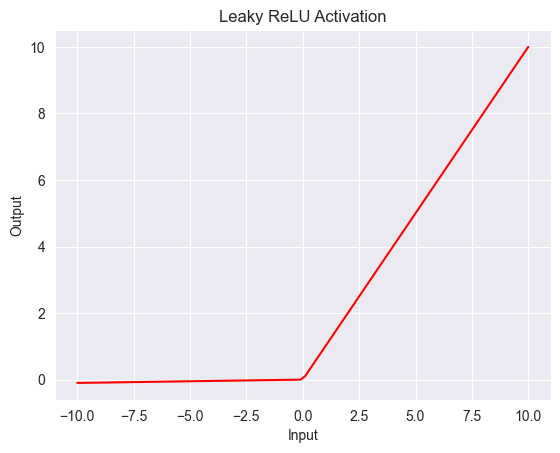

In [8]:
alpha = 0.01
y_leaky_relu = np.where(x > 0, x, alpha * x)

plt.plot(x, y_leaky_relu, color='red')
plt.title("Leaky ReLU Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

### Example: Leaky ReLU in Model

In [9]:
model_leaky_relu = keras.Sequential([
    layers.Dense(64, input_shape=(10,)),
    layers.LeakyReLU(alpha=0.01),
    layers.Dense(1, activation='sigmoid')
])

model_leaky_relu.summary()

C:\Users\Makrious\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

---

## ELU (Exponential Linear Unit)

- Smooth alternative to ReLU
- Helps gradient flow even when x < 0
- **Use when:** You want ReLU benefits + smoother negative region


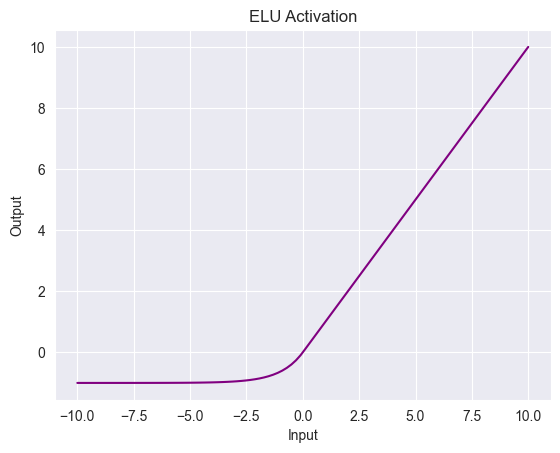

In [10]:
alpha = 1.0
y_elu = np.where(x > 0, x, alpha * (np.exp(x) - 1))

plt.plot(x, y_elu, color='purple')
plt.title("ELU Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

### Example: ELU in Model

In [11]:
model_elu = keras.Sequential([
    layers.Dense(32, activation='elu', input_shape=(10,)),
    layers.Dense(1, activation='sigmoid')
])

model_elu.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

---

## Softmax

- Converts raw logits to probabilities
- Output values sum to 1
- **Use when:** Multi-class classification (output layer)

In [12]:
z = np.array([2.0, 1.0, 0.1])
softmax = np.exp(z) / np.sum(np.exp(z))
print("Softmax Output:", softmax)
print("Sum of outputs:", np.sum(softmax))

Softmax Output: [0.65900114 0.24243297 0.09856589]
Sum of outputs: 1.0


### Example: Multi-class Classifier Using Softmax

In [13]:
model_softmax = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dense(3, activation='softmax')  # 3 classes
])

model_softmax.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,539 (6.01 KB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 0 (0.00 B)

---

## Summary: When to Use Each Activation

| Activation | When to Use |
|-------------|--------------|
| **ReLU** | Default for hidden layers |
| **Leaky ReLU / ELU** | When ReLU neurons die |
| **Tanh** | For small networks or centered outputs |
| **Sigmoid** | Binary classification output layer |
| **Softmax** | Multi-class output layer |

---

## Key Takeaways
- Activation functions give **neural networks power to learn nonlinear mappings**.
- The choice affects **gradient flow**, **convergence**, and **accuracy**.
- Always visualize and experiment to choose what works best for your data.

---